In [751]:
%pip install -vvv --default-timeout=120 --no-cache-dir numpy pandas matplotlib yfinance scikit-learn torch



Using pip 24.2 from /opt/anaconda3/lib/python3.12/site-packages/pip (python 3.12)
Non-user install because site-packages writeable
Created temporary directory: /private/var/folders/d_/w7lg5l0s3lgdmwvxxs5xwzb40000gn/T/pip-build-tracker-z6omrww_
Initialized build tracking at /private/var/folders/d_/w7lg5l0s3lgdmwvxxs5xwzb40000gn/T/pip-build-tracker-z6omrww_
Created build tracker: /private/var/folders/d_/w7lg5l0s3lgdmwvxxs5xwzb40000gn/T/pip-build-tracker-z6omrww_
Entered build tracker: /private/var/folders/d_/w7lg5l0s3lgdmwvxxs5xwzb40000gn/T/pip-build-tracker-z6omrww_
Created temporary directory: /private/var/folders/d_/w7lg5l0s3lgdmwvxxs5xwzb40000gn/T/pip-install-_r_w0s0x
Created temporary directory: /private/var/folders/d_/w7lg5l0s3lgdmwvxxs5xwzb40000gn/T/pip-ephem-wheel-cache-t83ioosj
Created temporary directory: /private/var/folders/d_/w7lg5l0s3lgdmwvxxs5xwzb40000gn/T/pip-unpack-gx2ct8cy
1 location(s) to search for versions of pip:
* https://pypi.org/simple/pip/
Fetching project page 

In [829]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import torch
import torch.nn as nn
import torch.optim as optim


from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error



In [831]:
device = torch.device('cpu')

In [833]:
ticker = 'MKS.L'
data_frame = yf.download(ticker, '2020-01-01')

/var/folders/d_/w7lg5l0s3lgdmwvxxs5xwzb40000gn/T/ipykernel_11059/2032674885.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_frame = yf.download(ticker, '2020-01-01')
[*********************100%***********************]  1 of 1 completed


In [835]:
data_frame

Price,Close,High,Low,Open,Volume
Ticker,MKS.L,MKS.L,MKS.L,MKS.L,MKS.L
Date,,,,,
2020-01-02,215.856903,217.256633,213.457388,215.057075,9411450
2020-01-03,214.057281,219.356212,212.157651,218.056483,9662024
2020-01-06,213.057480,213.657351,208.248427,213.157451,6611734
2020-01-07,218.356415,223.955303,217.156657,220.655959,9815245
2020-01-08,218.556381,219.856110,213.657350,217.156651,11192536
...,...,...,...,...,...
2025-08-18,346.600006,351.700012,345.399994,349.500000,9379546
2025-08-19,358.600006,360.500000,347.600006,348.500000,6806406


Text(0, 0.5, 'Close Price')

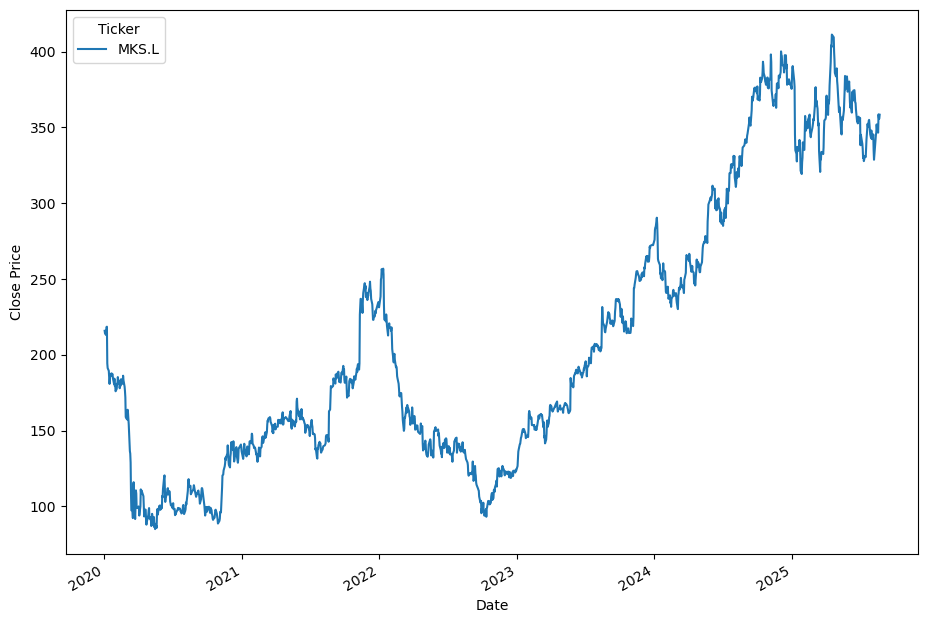

In [837]:
data_frame.Close.plot(figsize=(11, 8))
plt.ylabel("Close Price")

In [839]:
scaler = StandardScaler()
data_frame['Close'] = scaler.fit_transform(data_frame['Close'])

In [841]:
data_frame.Close

Ticker,MKS.L
Date,
2020-01-02,0.093295
2020-01-03,0.073318
2020-01-06,0.062220
2020-01-07,0.121040
2020-01-08,0.123260
...,...
2025-08-18,1.544585
2025-08-19,1.677789
2025-08-20,1.650038


In [843]:
sequence_length = 31
data = []

for i in range(len(data_frame) - sequence_length):
    data.append(data_frame.Close[i:i+sequence_length])

data = np.array(data)


In [845]:
data

array([[[ 0.09329461],
        [ 0.07331823],
        [ 0.0622201 ],
        ...,
        [-0.32732357],
        [-0.2990233 ],
        [-0.31067631]],

       [[ 0.07331823],
        [ 0.0622201 ],
        [ 0.12104   ],
        ...,
        [-0.2990233 ],
        [-0.31067631],
        [-0.26239966]],

       [[ 0.0622201 ],
        [ 0.12104   ],
        [ 0.12325969],
        ...,
        [-0.31067631],
        [-0.26239966],
        [-0.26295437]],

       ...,

       [[ 1.42581175],
        [ 1.35920981],
        [ 1.37586029],
        ...,
        [ 1.57233616],
        [ 1.54458535],
        [ 1.67778923]],

       [[ 1.35920981],
        [ 1.37586029],
        [ 1.33589906],
        ...,
        [ 1.54458535],
        [ 1.67778923],
        [ 1.65003842]],

       [[ 1.37586029],
        [ 1.33589906],
        [ 1.37364043],
        ...,
        [ 1.67778923],
        [ 1.65003842],
        [ 1.64670812]]])

In [847]:

train_size = int(0.8 * len(data))

X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
Y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
Y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [849]:
import torch.nn as nn

class PredictionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super ().__init__()

        self.num_layers = num_layers
        self.hidden_dim= hidden_dim

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc= nn.Linear(hidden_dim, output_dim)

    def forward (self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])
    
        return out

In [851]:
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

In [853]:
comparison = nn.MSELoss()
optimiser = optim.Adam(model.parameters(), lr = 0.01)

In [855]:
number_epochs = 200

for i in range(number_epochs):
    Y_train_pred = model(X_train)

    loss = comparison(Y_train_pred, Y_train) 

    if i % 25 == 0:
        print(i, loss.item())

    optimiser.zero_grad()
    loss.backward()
    optimiser.step()
    

0 0.6107949614524841
25 0.013340679928660393
50 0.0049893795512616634
75 0.004097322933375835
100 0.0037351411301642656
125 0.0034789724741131067
150 0.003228505840525031
175 0.0029761437326669693


In [856]:
sequence_length = 31
data = []

for i in range(len(data_frame) - sequence_length):
    data.append(data_frame.Close[i:i+sequence_length])

data = np.array(data)
train_size = int(0.8 * len(data))

X_train = torch.from_numpy(data[:train_size, :-1, :])

In [857]:
model.eval()

Y_test_pred = model(X_test)

Y_train_pred = scaler.inverse_transform(Y_train_pred.detach().cpu().numpy())
Y_train = scaler.inverse_transform(Y_train.detach().cpu().numpy())
Y_test_pred = scaler.inverse_transform(Y_test_pred.detach().cpu().numpy())
Y_test = scaler.inverse_transform(Y_test.detach().cpu().numpy())




In [858]:
train_data = root_mean_squared_error(Y_train[:,0], Y_train_pred[:,0])
test_data = root_mean_squared_error(Y_test[:,0], Y_test_pred[:,0])

In [859]:
train_data

4.713404

In [860]:
test_data

10.4412365

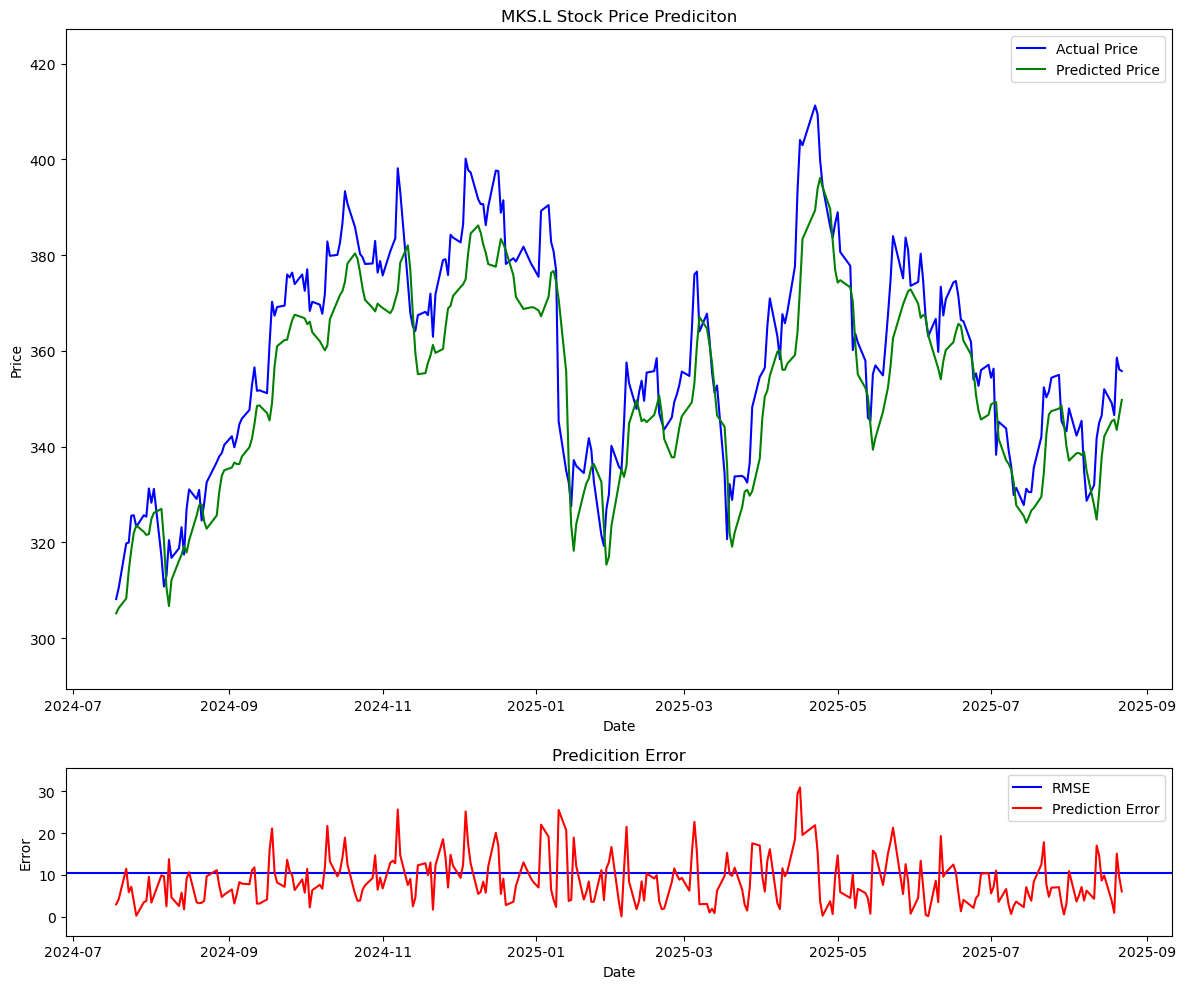

In [861]:
fig = plt.figure(figsize = (12,10))

grid = fig.add_gridspec(4, 1)

axis1 = fig.add_subplot(grid[:3, 0])
axis1.plot(data_frame.iloc[-len(Y_test):].index, Y_test, color = 'blue', label ='Actual Price')
axis1.plot(data_frame.iloc[-len(Y_test):].index, Y_test_pred, color = 'green', label ='Predicted Price')
axis1.legend()
plt.title(f"{ticker} Stock Price Prediciton")
plt.xlabel('Date')
plt.ylabel('Price')
axis1.margins(y=0.15)   


axis2 = fig.add_subplot(grid[3, 0])
axis2.axhline(test_data, color = 'blue', label = 'RMSE')
axis2.plot(data_frame[-len(Y_test):].index, abs(Y_test - Y_test_pred), 'r', label = 'Prediction Error')
axis2.legend()
plt.title('Predicition Error')
plt.xlabel('Date')
plt.ylabel('Error')
axis2.margins(y=0.15)

plt.tight_layout()
plt.show()